In [1]:
# Import Libraries

import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("feature_engineered_dataset.csv")
df.head()

,Brand,model,Year,kmDriven,Transmission,Owner,FuelType,AskPrice,km_per_year
0,Honda,City,2001,98000.0,Manual,second,Petrol,195000,3920.000000
1,Toyota,Innova,2009,190000.0,Manual,second,Diesel,375000,11176.470588
2,Volkswagen,VentoTest,2010,77246.0,Manual,first,Diesel,184999,4827.875000
3,Maruti Suzuki,Swift,2017,83500.0,Manual,second,Diesel,565000,9277.777778
4,Maruti Suzuki,Baleno,2019,45000.0,Automatic,first,Petrol,685000,6428.571429


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13982 entries, 0 to 13981
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         13982 non-null  object 
 1   model         13982 non-null  object 
 2   Year          13982 non-null  int64  
 3   kmDriven      13895 non-null  float64
 4   Transmission  13982 non-null  object 
 5   Owner         13982 non-null  object 
 6   FuelType      13982 non-null  object 
 7   AskPrice      13982 non-null  int64  
 8   km_per_year   13895 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 983.2+ KB


## Building Preprocessing Pipeline

In [4]:
# Step 1: Separate Features & Target

# Features
X = df.drop(columns="AskPrice")

# Target (Log Transformed)
y = np.log1p(df["AskPrice"])

print("Features & Target Separated Successfully")
print("-" * 40)

print(f"Feature Shape : {X.shape}")
print(f"Target Shape  : {y.shape}")

print("\nTarget Statistics (Log Scale)")
print(y.describe())

Features & Target Separated Successfully
----------------------------------------
Feature Shape : (13982, 8)
Target Shape  : (13982,)

Target Statistics (Log Scale)
count    13982.000000
mean        13.301582
std          0.918953
min          9.615872
25%         12.736704
50%         13.235694
75%         13.805461
max         17.565015
Name: AskPrice, dtype: float64


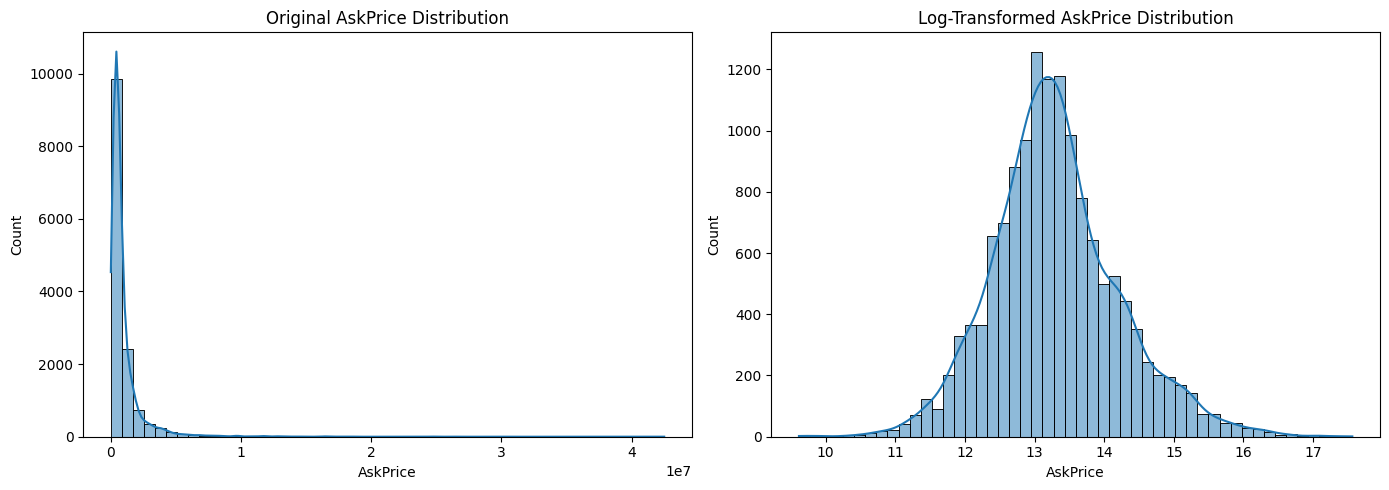

In [5]:
# Step 2: Compare Original vs Log-Transformed Target

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,5))

# Original Target
plt.subplot(1,2,1)
sns.histplot(df["AskPrice"], bins=50, kde=True)
plt.title("Original AskPrice Distribution")

# Log Target
plt.subplot(1,2,2)
sns.histplot(y, bins=50, kde=True)
plt.title("Log-Transformed AskPrice Distribution")

plt.tight_layout()
plt.show()

**Interpretation:**
- The original target variable exhibits an extremely right-skewed distribution, with a small number of luxury vehicles contributing disproportionately high asking prices. After applying the natural logarithm transformation (log1p), the distribution becomes significantly more symmetric and closer to a normal distribution. This transformation reduces the influence of extreme values, stabilizes variance, and enables regression algorithms to learn underlying pricing patterns more effectively. During deployment, predicted logarithmic prices will be converted back to the original price scale using the inverse transformation (expm1) to provide interpretable price estimates.

In [6]:
# Step 3: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train-Test Split Completed")
print("-" * 30)

print(f"Training Set : {X_train.shape}")
print(f"Testing Set  : {X_test.shape}")

Train-Test Split Completed
------------------------------
Training Set : (11185, 8)
Testing Set  : (2797, 8)


In [7]:
# Step 4: Identify Numerical & Categorical Features

num_attributes = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

cat_attributes = X_train.select_dtypes(
    exclude=[np.number]
).columns.tolist()

print("Feature Categories")
print("-" * 60)

print(f"Numerical Features ({len(num_attributes)})")
print(num_attributes)

print()

print(f"Categorical Features ({len(cat_attributes)})")
print(cat_attributes)

Feature Categories
------------------------------------------------------------
Numerical Features (3)
['Year', 'kmDriven', 'km_per_year']

Categorical Features (5)
['Brand', 'model', 'Transmission', 'Owner', 'FuelType']


In [8]:
# Step 5: Build the Preprocessing Pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# Numerical Pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical Pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# Combine Pipelines
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_attributes),
    ("cat", cat_pipeline, cat_attributes)
])


print("Preprocessing Pipeline Created Successfully!")
print("-" * 60)

print(preprocessor)

Preprocessing Pipeline Created Successfully!
------------------------------------------------------------
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Year', 'kmDriven', 'km_per_year']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Brand', 'model', 'Transmission', 'Owner',
                                  'FuelType'])])


In [9]:
# Step 6: Fit & Transform

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Data Preprocessing Completed")
print("-" * 30)

print(f"Training Shape : {X_train_prepared.shape}")
print(f"Testing Shape  : {X_test_prepared.shape}")

Data Preprocessing Completed
------------------------------
Training Shape : (11185, 467)
Testing Shape  : (2797, 467)


In [10]:
print(type(X_train_prepared))
print(type(X_test_prepared))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>


In [11]:
# Step 7: Encoded Feature Information

encoded_feature_names = preprocessor.get_feature_names_out()

print("Encoded Feature Information")
print("-" * 40)

print(f"Original Features    : {len(X.columns)}")
print(f"Transformed Features : {len(encoded_feature_names)}")

print("\nFirst 20 Features:\n")

for feature in encoded_feature_names[:20]:
    print(feature)

Encoded Feature Information
----------------------------------------
Original Features    : 8
Transformed Features : 467

First 20 Features:

num__Year
num__kmDriven
num__km_per_year
cat__Brand_Ambassador
cat__Brand_Ashok
cat__Brand_Aston Martin
cat__Brand_Audi
cat__Brand_BMW
cat__Brand_Bajaj
cat__Brand_Bentley
cat__Brand_Chevrolet
cat__Brand_Datsun
cat__Brand_Fiat
cat__Brand_Force
cat__Brand_Ford
cat__Brand_Honda
cat__Brand_Hummer
cat__Brand_Hyundai
cat__Brand_Isuzu
cat__Brand_Jaguar


In [12]:
feature_df = pd.DataFrame({
    "Feature Name": encoded_feature_names
})

display(feature_df)

,Feature Name
0,num__Year
1,num__kmDriven
2,num__km_per_year
3,cat__Brand_Ambassador
4,cat__Brand_Ashok
...,...
462,cat__Owner_second
463,cat__FuelType_Diesel
464,cat__FuelType_Hybrid
465,cat__FuelType_Hybrid/CNG


## Baseline Regression Model Training

In [13]:
# Step 1: Import Machine Learning Models & Evaluation Metrics

import time

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("All Models Imported Successfully!")

All Models Imported Successfully!


In [14]:
# Step 2: Create Model Dictionary

models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    )

}

print(f"Total Models : {len(models)}")

Total Models : 6


In [15]:
# Step 3: Train & Evaluate Models

results = []
trained_models = {}

n = X_test_prepared.shape[0]
p = X_train_prepared.shape[1]

for name, model in models.items():

    print(f"Training {name}...")


    # Training Time
    start_time = time.time()

    model.fit(X_train_prepared, y_train)

    end_time = time.time()

    training_time = end_time - start_time

    trained_models[name] = model

    
    # Prediction
    y_pred = model.predict(X_test_prepared)

   
    # Evaluation Metrics
    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)

    adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

 
    # Cross Validation
    cv_score = cross_val_score(
        model,
        X_train_prepared,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    ).mean()


    # Store Results
    results.append({

        "Model": name,

        "MAE": mae,

        "RMSE": rmse,

        "R² Score": r2,

        "Adjusted R²": adjusted_r2,

        "CV R²": cv_score,

        "Training Time (sec)": training_time

    })

print("\nAll Models Trained Successfully!")

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training XGBoost...

All Models Trained Successfully!


In [16]:
# Step 4: Model Comparison Table

results_df = (
    pd.DataFrame(results)
      .sort_values(
          by="R² Score",
          ascending=False
      )
      .reset_index(drop=True)
)

results_df

,Model,MAE,RMSE,R² Score,Adjusted R²,CV R²,Training Time (sec)
0,Linear Regression,0.191140,0.293832,0.891715,0.870002,0.869553,0.066246
1,XGBoost,0.206125,0.311190,0.878543,0.854189,0.866122,1.447995
2,Random Forest,0.198505,0.311218,0.878521,0.854163,0.863376,5.477718
3,Extra Trees,0.198075,0.321212,0.870594,0.844646,0.854875,8.851058
4,Decision Tree,0.239494,0.388070,0.811117,0.773244,0.788324,0.774236
5,Gradient Boosting,0.286694,0.400682,0.798641,0.758266,0.794604,1.379306


In [17]:
# Step 5: Round Numerical Values

results_df = results_df.round({

    "MAE":4,

    "RMSE":4,

    "R² Score":4,

    "Adjusted R²":4,

    "CV R²":4,

    "Training Time (sec)":3

})

results_df

,Model,MAE,RMSE,R² Score,Adjusted R²,CV R²,Training Time (sec)
0,Linear Regression,0.1911,0.2938,0.8917,0.8700,0.8696,0.066
1,XGBoost,0.2061,0.3112,0.8785,0.8542,0.8661,1.448
2,Random Forest,0.1985,0.3112,0.8785,0.8542,0.8634,5.478
3,Extra Trees,0.1981,0.3212,0.8706,0.8446,0.8549,8.851
4,Decision Tree,0.2395,0.3881,0.8111,0.7732,0.7883,0.774
5,Gradient Boosting,0.2867,0.4007,0.7986,0.7583,0.7946,1.379


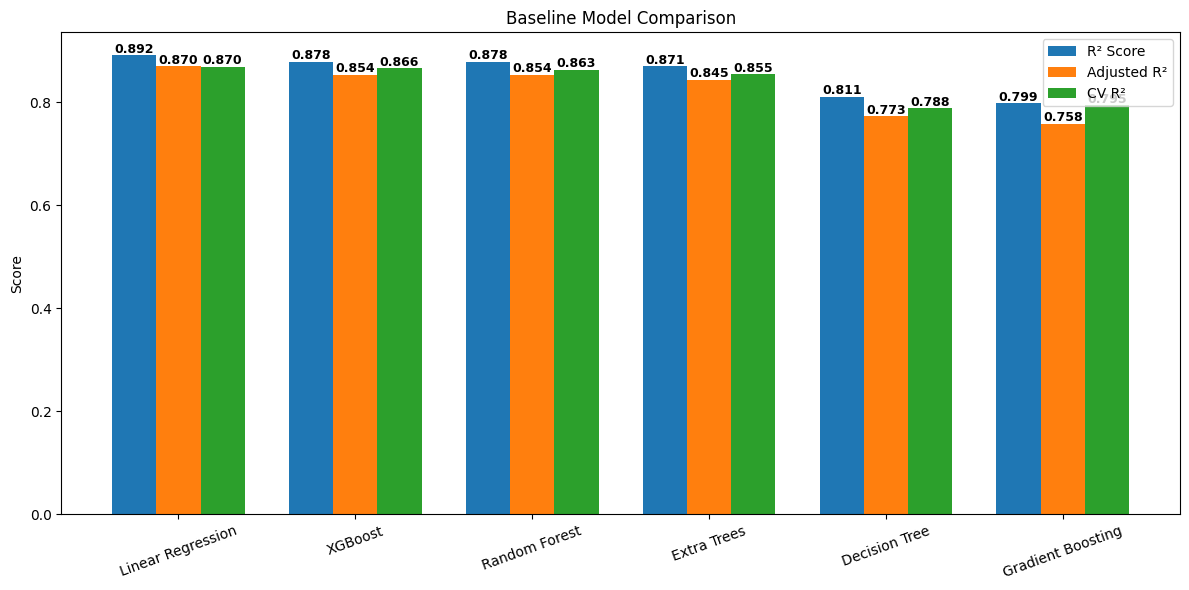

In [18]:
# Step 6: Visualize Model Performance

import matplotlib.pyplot as plt

metrics = ["R² Score", "Adjusted R²", "CV R²"]

plt.figure(figsize=(12,6))

bar_width = 0.25

x = range(len(results_df))

for i, metric in enumerate(metrics):

    bars = plt.bar(
        [p + bar_width*i for p in x],
        results_df[metric],
        width=bar_width,
        label=metric
    )

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x()+bar.get_width()/2,
            height+0.005,
            f"{height:.3f}",
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

plt.xticks(
    [p+bar_width for p in x],
    results_df["Model"],
    rotation=20
)

plt.ylabel("Score")

plt.title("Baseline Model Comparison")

plt.legend()

plt.tight_layout()

plt.show()

In [19]:
# Step 7: Best Baseline Model

best_model = results_df.iloc[0]

print("Best Baseline Model")
print("-"*40)

print(f"Model        : {best_model['Model']}")
print(f"MAE          : {best_model['MAE']:.4f}")
print(f"RMSE         : {best_model['RMSE']:.4f}")
print(f"R² Score     : {best_model['R² Score']:.4f}")
print(f"CV R²        : {best_model['CV R²']:.4f}")

Best Baseline Model
----------------------------------------
Model        : Linear Regression
MAE          : 0.1911
RMSE         : 0.2938
R² Score     : 0.8917
CV R²        : 0.8696


# Hyperparameter Tuning

In [20]:
# Step 1: Import Hyperparameter Tuning Libraries

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge, Lasso

print("Hyperparameter Tuning Libraries Imported Successfully!")

Hyperparameter Tuning Libraries Imported Successfully!


In [21]:
# Step 2: Hyperparameter Tuning Function

def tune_model(model, param_dist, X_train, y_train, cv=5, n_iter=20):

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring="r2",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    random_search.fit(X_train, y_train)

    return random_search

In [22]:
# Step 3: Ridge Regression Hyperparameter Space

ridge_params = {

    "alpha": np.logspace(-3, 3, 100),

    "solver": [
        "auto",
        "svd",
        "cholesky",
        "lsqr",
        "sag"
    ]
}

In [23]:
# Step 4: Tune Ridge Regression

ridge_search = tune_model(
    Ridge(),
    ridge_params,
    X_train_prepared,
    y_train
)

best_ridge = ridge_search.best_estimator_

print("Best Ridge Parameters")
print("-"*50)

print(ridge_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Ridge Parameters
--------------------------------------------------
{'solver': 'sag', 'alpha': 0.2009233002565048}


In [24]:
# Step 5: Lasso Hyperparameter Space

lasso_params = {

    "alpha": np.logspace(-4, 1, 100),

    "max_iter": [3000,5000,8000]
}

In [25]:
# Step 6: Tune Lasso Regression

lasso_search = tune_model(
    Lasso(random_state=42),
    lasso_params,
    X_train_prepared,
    y_train
)

best_lasso = lasso_search.best_estimator_

print("Best Lasso Parameters")
print("-"*50)

print(lasso_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Lasso Parameters
--------------------------------------------------
{'max_iter': 8000, 'alpha': 0.00011233240329780277}


In [26]:
# Step 7: Evaluation Function

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)

    print(type(model).__name__)
    print("-"*10)

    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")

In [27]:
evaluate_model(
    best_ridge,
    X_test_prepared,
    y_test
)

evaluate_model(
    best_lasso,
    X_test_prepared,
    y_test
)

Ridge
----------
MAE : 0.1911
RMSE: 0.2937
R²  : 0.8918
Lasso
----------
MAE : 0.1965
RMSE: 0.3016
R²  : 0.8859


**Interpretation:**
- Ridge improved the R² score by only 0.0001, which is practically negligible.
- Lasso performed worse because it shrinks coefficients to zero, causing some information loss.
- This indicates that multicollinearity is not a major issue in your dataset, and the baseline Linear Regression is already close to optimal.

- So we'll retain Linear Regression as our best linear model.

In [28]:
# Step 8: Random Forest Hyperparameter Space

rf_params = {

    "n_estimators": [200, 300, 500],

    "max_depth": [10, 20, 30, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"],

    "bootstrap": [True]
}

In [29]:
# Step 9: Tune Random Forest

rf_search = tune_model(

    RandomForestRegressor(random_state=42),

    rf_params,

    X_train_prepared,

    y_train,

    n_iter=20

)

best_rf = rf_search.best_estimator_

print("Best Random Forest Parameters")
print("-"*50)

print(rf_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Random Forest Parameters
--------------------------------------------------
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}


In [30]:
evaluate_model(
    best_rf,
    X_test_prepared,
    y_test
)

RandomForestRegressor
----------
MAE : 0.2050
RMSE: 0.3188
R²  : 0.8726


In [31]:
# Step 10: XGBoost Hyperparameter Space

xgb_params = {

    "n_estimators": [200, 300, 500],

    "max_depth": [3, 5, 7, 9],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "subsample": [0.8, 1.0],

    "colsample_bytree": [0.8, 1.0],

    "min_child_weight": [1, 3, 5]
}

In [32]:
# Step 11: Tune XGBoost

xgb_search = tune_model(

    XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),

    xgb_params,

    X_train_prepared,

    y_train,

    n_iter=20

)

best_xgb = xgb_search.best_estimator_

print("Best XGBoost Parameters")
print("-"*50)

print(xgb_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGBoost Parameters
--------------------------------------------------
{'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [33]:
evaluate_model(
    best_xgb,
    X_test_prepared,
    y_test
)

XGBRegressor
----------
MAE : 0.1883
RMSE: 0.2988
R²  : 0.8881


## Final Evaluation Function (Original Price Scale)

In [34]:
# Step 1: Evaluate Models on the Original Price Scale

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_original_scale(model, X_test, y_test_log):

    # Predictions (log scale)
    y_pred_log = model.predict(X_test)

    # Convert back to original price
    y_test_original = np.expm1(y_test_log)
    y_pred_original = np.expm1(y_pred_log)

    # Metrics
    mae = mean_absolute_error(y_test_original, y_pred_original)

    rmse = np.sqrt(
        mean_squared_error(
            y_test_original,
            y_pred_original
        )
    )

    r2 = r2_score(
        y_test_original,
        y_pred_original
    )

    return mae, rmse, r2

In [35]:
# Step 2: Evaluate Best Models on Original Price Scale

final_results = []

models = {

    "Linear Regression": trained_models["Linear Regression"],

    "Ridge": best_ridge,

    "Random Forest": best_rf,

    "XGBoost": best_xgb

}

for name, model in models.items():

    mae, rmse, r2 = evaluate_original_scale(
        model,
        X_test_prepared,
        y_test
    )

    final_results.append({

        "Model": name,

        "MAE (₹)": round(mae),

        "RMSE (₹)": round(rmse),

        "R² Score": round(r2,4)

    })

final_results_df = pd.DataFrame(final_results)

final_results_df.sort_values(
    by="R² Score",
    ascending=False,
    inplace=True
)

final_results_df.reset_index(
    drop=True,
    inplace=True
)

final_results_df

,Model,MAE (₹),RMSE (₹),R² Score
0,XGBoost,176962,806906,0.6691
1,Ridge,186205,812702,0.6644
2,Linear Regression,186671,813195,0.6640
3,Random Forest,202932,883849,0.6030


## Create the Final Comparison Table

In [36]:
comparison_df = pd.DataFrame({

    "Model": [

        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "Random Forest",
        "XGBoost",
        "XGBoost"

    ],

    "Version": [

        "Baseline",
        "Tuned",
        "Tuned",
        "Baseline",
        "Tuned",
        "Baseline",
        "Tuned"

    ],

    "MAE (Log)": [

        0.1911,
        0.1911,
        0.1965,
        0.1985,
        0.2050,
        0.2061,
        0.1883

    ],

    "RMSE (Log)": [

        0.2938,
        0.2937,
        0.3016,
        0.3112,
        0.3188,
        0.3112,
        0.2988

    ],

    "R² (Log)": [

        0.8917,
        0.8918,
        0.8859,
        0.8785,
        0.8726,
        0.8785,
        0.8881

    ]

})

comparison_df

,Model,Version,MAE (Log),RMSE (Log),R² (Log)
0,Linear Regression,Baseline,0.1911,0.2938,0.8917
1,Ridge Regression,Tuned,0.1911,0.2937,0.8918
2,Lasso Regression,Tuned,0.1965,0.3016,0.8859
3,Random Forest,Baseline,0.1985,0.3112,0.8785
4,Random Forest,Tuned,0.2050,0.3188,0.8726
5,XGBoost,Baseline,0.2061,0.3112,0.8785
6,XGBoost,Tuned,0.1883,0.2988,0.8881


**Interpretation:**
- The baseline and tuned model comparison demonstrates that different algorithms respond differently to hyperparameter optimization. Ridge Regression achieved the highest performance among the linear models with an R² score of **0.8918**, although the improvement over the baseline Linear Regression **(0.8917)** was negligible, suggesting that regularization offered little additional benefit.

- Among the ensemble methods, XGBoost showed the largest improvement after tuning, increasing its R² score from **0.8785** to **0.8881** while simultaneously reducing both MAE and RMSE. In contrast, Random Forest experienced a slight decrease in performance after tuning, indicating that the baseline model already generalized well for this dataset.

- Overall, the results suggest that the used car pricing problem becomes nearly linear after feature engineering and logarithmic transformation of the target variable. However, when predictions were converted back to the original rupee scale, the tuned XGBoost model produced the lowest prediction error, making it the most suitable model for deployment.

**Business Recommendation:**
- The final pricing engine should deploy the tuned XGBoost model because it provides the most accurate predictions on actual vehicle prices while effectively capturing nonlinear relationships between vehicle characteristics and resale value. Although simpler linear models achieved comparable performance on the transformed target, XGBoost produced lower prediction errors in real monetary values, which is more relevant for customers and dealerships using the application.

## Final Model Evaluation - XG Boost

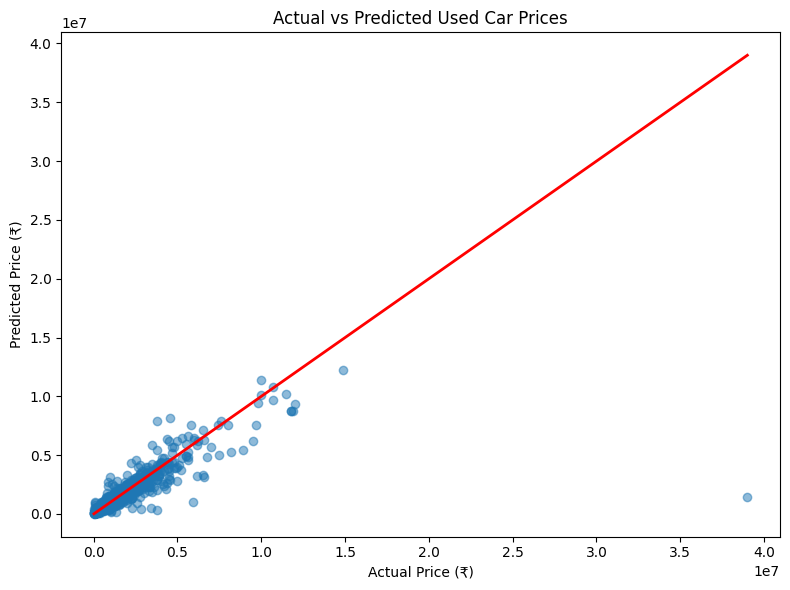

In [37]:
# Step 1:  Actual vs Predicted Prices


# Predictions (Log Scale)
y_pred_log = best_xgb.predict(X_test_prepared)

# Convert back to Original Scale
y_actual = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

plt.figure(figsize=(8,6))

plt.scatter(
    y_actual,
    y_pred,
    alpha=0.5
)

# Perfect Prediction Line
plt.plot(
    [y_actual.min(), y_actual.max()],
    [y_actual.min(), y_actual.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title("Actual vs Predicted Used Car Prices")

plt.tight_layout()
plt.show()

**Interpretation:**
- The scatter plot compares the actual asking prices with the prices predicted by the tuned XGBoost model. Most observations are concentrated around the **45-degree** reference line, indicating that the model produces predictions that are generally close to the true market values. The spread of points increases for higher-priced vehicles, suggesting that predicting luxury and premium cars is more challenging due to their greater price variability. Nevertheless, the model captures the overall pricing trend effectively across different vehicle segments.

**Business Recommendation:**
- The model demonstrates strong predictive capability for the majority of used vehicles, making it suitable for assisting dealerships and online marketplaces in estimating fair resale prices. Although prediction uncertainty increases for luxury vehicles, the pricing recommendations remain sufficiently accurate for practical decision-making.

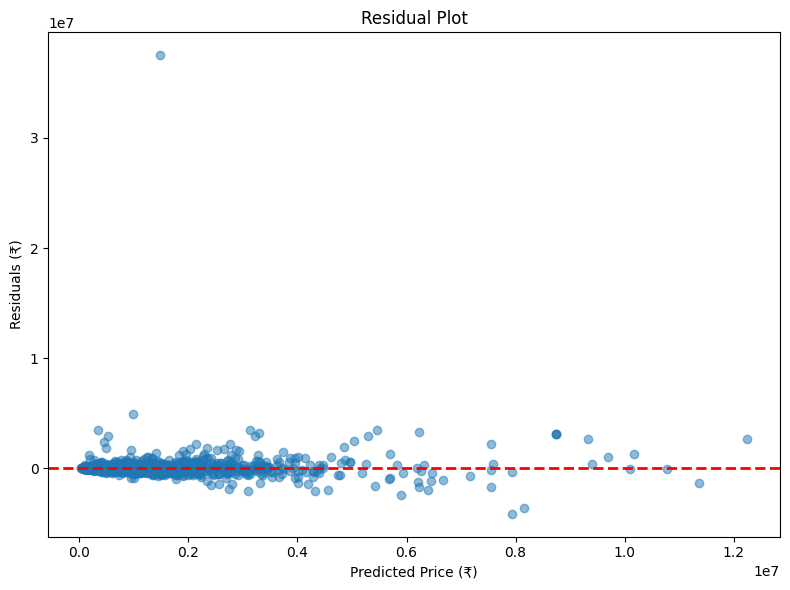

In [38]:
# Step 2: Residual Plot

residuals = y_actual - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Price (₹)")
plt.ylabel("Residuals (₹)")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

**Interpretation:**
- The residual plot shows that prediction errors are distributed around the **zero line** without any strong systematic pattern, indicating that the model does not exhibit significant bias across most price ranges. However, the spread of residuals increases for higher-priced vehicles, suggesting greater prediction uncertainty in the luxury vehicle segment. This behavior is expected because premium vehicles often have unique characteristics that are difficult to capture completely using structured features alone.

**Business Recommendation:**
- The absence of a clear pattern in the residuals indicates that the model generalizes well across most used car categories. Additional features such as vehicle condition, accident history, service records, or regional demand could further improve predictions for premium vehicles.

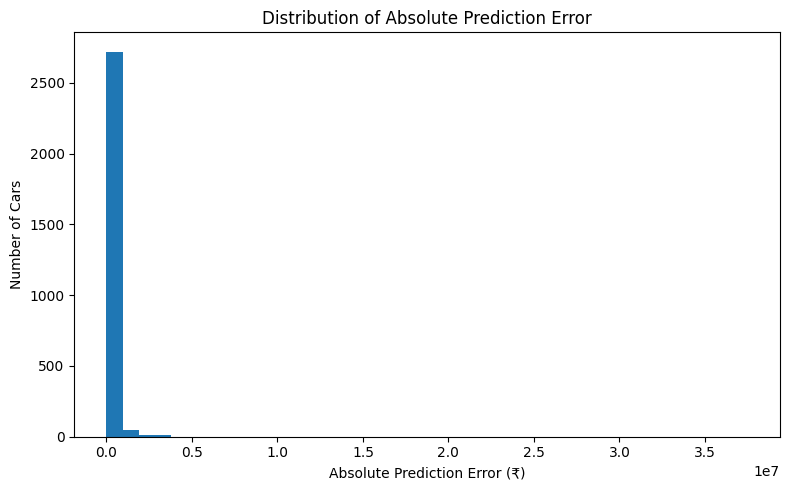

In [39]:
# Step 3: Absolute Error Distribution

absolute_error = np.abs(y_actual - y_pred)

plt.figure(figsize=(8,5))

plt.hist(
    absolute_error,
    bins=40
)

plt.xlabel("Absolute Prediction Error (₹)")
plt.ylabel("Number of Cars")
plt.title("Distribution of Absolute Prediction Error")

plt.tight_layout()
plt.show()

In [40]:
# Summary Statistics

print("Absolute Error Summary")
print("-"*40)

print(pd.Series(absolute_error).describe())

print("\nPercentiles")

print(pd.Series(absolute_error).quantile(
    [0.50,0.75,0.90,0.95,0.99]
))

Absolute Error Summary
----------------------------------------
count    2.797000e+03
mean     1.769624e+05
std      7.874025e+05
min      5.681250e+01
25%      2.963900e+04
50%      6.810441e+04
75%      1.469424e+05
max      3.751637e+07
Name: AskPrice, dtype: float64

Percentiles
0.50    6.810441e+04
0.75    1.469424e+05
0.90    3.504954e+05
0.95    5.731818e+05
0.99    1.884268e+06
Name: AskPrice, dtype: float64


**Interpretation:**
- The distribution of Absolute Prediction Error is **highly right-skewed**, indicating that the tuned XGBoost model makes small prediction errors for most vehicles, while only a few cars have large errors. The median absolute error is **₹68,104**, meaning half of all predictions differ from the actual price by less than this amount. Additionally, 75% of predictions have an error below **₹1.46 lakh**, and 90% are within **₹3.50 lakh**.

- The long right tail is driven by a small number of expensive vehicles, with the maximum error reaching **₹3.75 crore**. These large monetary errors are expected for premium and luxury cars, where even modest percentage deviations result in substantial absolute errors.

- Overall, the error distribution suggests that the model provides accurate and reliable price predictions for the majority of used cars, with larger errors mainly concentrated in the luxury segment.

**Business Recommendation:**
- The model is suitable for dealership pricing, online marketplaces, and vehicle valuation tools, as it delivers accurate price estimates for most used cars. To further improve predictions for high-end and luxury vehicles, additional features such as vehicle condition, trim level, optional features, ownership history, and service records should be incorporated into the model.

## Feature Importance & Model Explainability

In [41]:
# Part 1 — Extract Feature Importance

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Feature importance from XGBoost
importance = best_xgb.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

})

# Sort descending
importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df.head(20)

,Feature,Importance
0,cat__Brand_Maruti Suzuki,0.067032
1,cat__Brand_Mercedes-Benz,0.048216
2,cat__Brand_BMW,0.040078
3,cat__Brand_Toyota,0.031908
4,cat__Brand_Land Rover,0.027932
5,cat__Brand_Renault,0.025955
6,cat__FuelType_Diesel,0.024718
7,cat__Brand_Honda,0.023782
8,cat__model_RX,0.023309
9,cat__Brand_Lexus,0.019970


In [42]:
# Part 2 - Display Top 20 Features

importance_df.head(20)

,Feature,Importance
0,cat__Brand_Maruti Suzuki,0.067032
1,cat__Brand_Mercedes-Benz,0.048216
2,cat__Brand_BMW,0.040078
3,cat__Brand_Toyota,0.031908
4,cat__Brand_Land Rover,0.027932
5,cat__Brand_Renault,0.025955
6,cat__FuelType_Diesel,0.024718
7,cat__Brand_Honda,0.023782
8,cat__model_RX,0.023309
9,cat__Brand_Lexus,0.019970


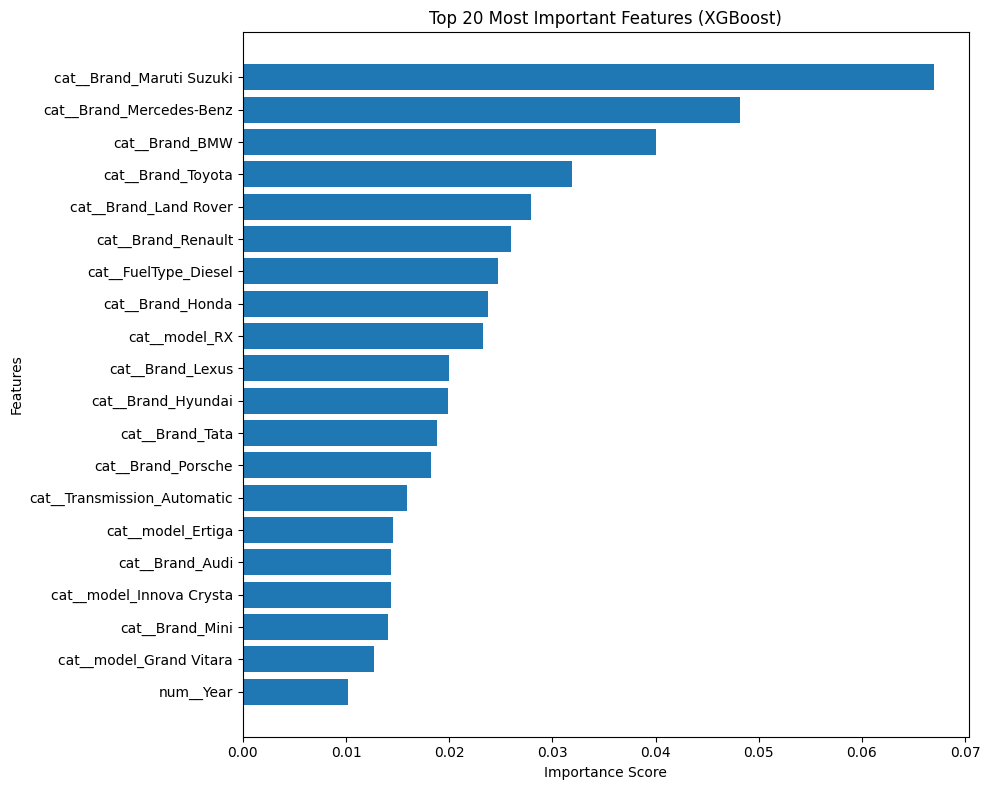

In [43]:
# Part 3 — Plot Feature Importance

plt.figure(figsize=(10,8))

top_features = importance_df.head(20)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Most Important Features (XGBoost)")

plt.tight_layout()
plt.show()

In [44]:
# Part 4 — Cumulative Importance
importance_df["Cumulative Importance"] = (
    importance_df["Importance"].cumsum()
)

importance_df.head(20)

,Feature,Importance,Cumulative Importance
0,cat__Brand_Maruti Suzuki,0.067032,0.067032
1,cat__Brand_Mercedes-Benz,0.048216,0.115248
2,cat__Brand_BMW,0.040078,0.155326
3,cat__Brand_Toyota,0.031908,0.187234
4,cat__Brand_Land Rover,0.027932,0.215166
5,cat__Brand_Renault,0.025955,0.241121
6,cat__FuelType_Diesel,0.024718,0.265840
7,cat__Brand_Honda,0.023782,0.289621
8,cat__model_RX,0.023309,0.312930
9,cat__Brand_Lexus,0.019970,0.332900


**Interpretation:**
- The feature importance analysis indicates that Brand is the strongest determinant of a used car's resale value. Several manufacturer-specific categories, including** Maruti Suzuki, Mercedes-Benz, BMW, Toyota, Land Rover, Renault, Honda, Hyundai, Tata, Porsche, Audi, and Lexus**, appear among the most influential predictors. This suggests that brand reputation, market demand, reliability, and resale perception play a significant role in determining vehicle prices.

- Specific vehicle models, such as **RX, Ertiga, Innova Crysta, and Grand Vitara**, also contribute substantially to price prediction, highlighting that market demand varies considerably even within the same manufacturer. Among the numerical variables, Manufacturing Year is one of the most influential continuous features, confirming that newer vehicles generally retain higher resale values due to lower depreciation. Additionally, **Automatic Transmission** and **Diesel Fuel Type** appear among the top predictors, indicating that drivetrain characteristics also influence market pricing.

- The cumulative importance shows that the **top 20** transformed features account for approximately **48.6%** of the model's total predictive power, demonstrating that the model relies on a relatively small set of highly informative features while still leveraging many additional variables to improve prediction accuracy.

**Business Recommendation:**
- Dealerships and online vehicle marketplaces should prioritize brand reputation, vehicle model, manufacturing year, and drivetrain characteristics when estimating resale prices, as these factors have the greatest influence on market value. Brand-specific pricing strategies should be adopted because premium manufacturers and popular models consistently command higher resale prices. From a machine learning perspective, the results confirm that the selected features effectively capture the key drivers of vehicle valuation, enabling the tuned XGBoost model to generate accurate and reliable price predictions across different segments of the used car market.

## Group Feature Importance

In [45]:
# Step 1- Group Feature Importance by Original Feature

grouped_importance = {}

for feature, importance in zip(feature_names, best_xgb.feature_importances_):

    if feature.startswith("num__Year"):
        original = "Year"

    elif feature.startswith("num__kmDriven"):
        original = "kmDriven"

    elif feature.startswith("num__km_per_year"):
        original = "km_per_year"

    elif feature.startswith("cat__Brand"):
        original = "Brand"

    elif feature.startswith("cat__model"):
        original = "Model"

    elif feature.startswith("cat__Transmission"):
        original = "Transmission"

    elif feature.startswith("cat__Owner"):
        original = "Owner"

    elif feature.startswith("cat__FuelType"):
        original = "FuelType"

    else:
        original = "Other"

    grouped_importance[original] = (
        grouped_importance.get(original, 0) + importance
    )

grouped_importance_df = (
    pd.DataFrame({
        "Feature": grouped_importance.keys(),
        "Importance": grouped_importance.values()
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

grouped_importance_df["Importance (%)"] = (
    grouped_importance_df["Importance"] * 100
).round(2)

grouped_importance_df

,Feature,Importance,Importance (%)
0,Model,0.480496,48.05
1,Brand,0.457105,45.71
2,FuelType,0.030357,3.04
3,Transmission,0.017399,1.74
4,Year,0.010228,1.02
5,Owner,0.002233,0.22
6,kmDriven,0.001115,0.11
7,km_per_year,0.001068,0.11


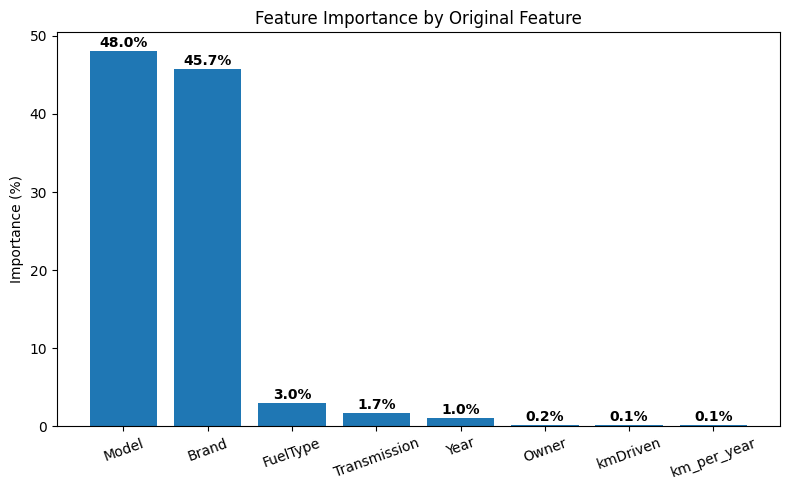

In [46]:
# Step 2: Plot Grouped Importance

plt.figure(figsize=(8,5))

plt.bar(
    grouped_importance_df["Feature"],
    grouped_importance_df["Importance (%)"]
)

# Value labels
for i, value in enumerate(grouped_importance_df["Importance (%)"]):
    plt.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.ylabel("Importance (%)")
plt.title("Feature Importance by Original Feature")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

**Interpretation:**
- The feature importance analysis shows that **Model (48.04%)** and **Brand (45.71%)** are by far the most influential features, together contributing over **93%** of the model's predictive power. This indicates that the specific vehicle model and manufacturer are the primary factors determining the resale price of used cars.

- Among the remaining features, **FuelType (3.04%), Transmission (1.74%)**, and **Year (1.02%)** have a relatively small but meaningful influence on price prediction. In contrast, **Owner (0.22%), kmDriven (0.11%)**, and **km_per_year (0.11%**) contribute very little to the model, suggesting they provide limited additional information once the vehicle's model and brand are known.

- Overall, the results indicate that the XGBoost model relies primarily on vehicle identity **(Model and Brand)** to estimate resale prices, while other features play a supporting role.

**Business Recommendation**
- Dealerships and online automobile marketplaces should prioritize collecting accurate Model and Brand information, as these are the most critical factors influencing vehicle prices. Ensuring high-quality data for these features will lead to more reliable pricing recommendations.

- Although features such as FuelType, Transmission, and Year have a smaller impact, they should still be retained to improve prediction accuracy. Features with very low importance, such as Owner, kmDriven, and km_per_year, may be reviewed in future model iterations, but should not be removed without validating their impact on overall model performance.

## Save Tuned XG Boost Model and Preprocessing Pipeline

In [47]:
# Step 1: Import Libraries

import joblib
import os

In [48]:
# Step 2: Create Folder to Save Model

os.makedirs("artifacts", exist_ok=True)

print("Artifacts Folder Created Successfully!")

Artifacts Folder Created Successfully!


In [49]:
# Step 3: Save Preprocessing Pipeline

joblib.dump(
    preprocessor,
    "artifacts/preprocessor.pkl"
)

print("Preprocessing Pipeline Saved Successfully!")

Preprocessing Pipeline Saved Successfully!


In [50]:
# Step 4: Save Tuned XGBoost Model

joblib.dump(
    best_xgb,
    "artifacts/model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [51]:
# Step 5: Verify Saved Files

print(os.listdir("artifacts"))

['model.pkl', 'preprocessor.pkl']


In [52]:
# Step 6: Load Saved Files

loaded_preprocessor = joblib.load("artifacts/preprocessor.pkl")
loaded_model = joblib.load("artifacts/model.pkl")

print("Files Loaded Successfully!")

Files Loaded Successfully!


In [53]:
# Step 7: Test Prediction with Saved Files

sample = X_test.iloc[[0]]

sample_prepared = loaded_preprocessor.transform(sample)

prediction_log = loaded_model.predict(sample_prepared)[0]

prediction_price = np.expm1(prediction_log)

actual_price = np.expm1(y_test.iloc[0])

print("Actual Price    : ₹{:,.0f}".format(actual_price))
print("Predicted Price : ₹{:,.0f}".format(prediction_price))

Actual Price    : ₹4,525,111
Predicted Price : ₹2,870,806


In [54]:
import joblib

# Load the saved model
model = joblib.load("artifacts/model.pkl")

print(type(model))

# Use one sample from the test set
sample = X_test.iloc[[0]]

# Transform it using the same preprocessor
sample_processed = preprocessor.transform(sample)

# Predict
pred = model.predict(sample_processed)[0]

print("Model Prediction :", pred)
print("Actual y_test    :", y_test.iloc[0])

<class 'xgboost.sklearn.XGBRegressor'>
Model Prediction : 14.870104
Actual y_test    : 15.325152886191068
